# Nearly-Periodic Coupled Oscillators: ML Model Evaluation

## Overview

This notebook evaluates neural network (NN) flow maps for the nearly-periodic coupled oscillators (NPCO) problem.

In particular, this notebook will:
1. Load trained NN flow maps from specified checkpoint files.
2. Benchmark the NN forward pass runtime.
3. Generate and compare trajectories using the NN flow maps versus reference solutions, supporting both one-step and recursive prediction modes.

## Mathematical Model

The system is described by the Hamiltonian:

$$ H_\varepsilon (q_1,q_2,p_1,p_2) = \frac{1}{2} (q_1^2 + p_1^2 ) + \frac{1}{2} \varepsilon (q_2^2 + p_2^2 )  + \varepsilon U(q_1,q_2) $$

where the coupling potential is:
$$ U(q_1,q_2) = q_1 q_2 \sin(2q_1 + 2q_2) $$

The equations of motion are:
$$ \begin{cases} \dot{q}_1 = p_1 \qquad & \dot{p}_1 = -q_1 - \varepsilon \partial_{q_1} U(q_1,q_2) \\ \dot{q}_2 = \varepsilon p_2 \qquad & \dot{p}_2 = -\varepsilon q_2 - \varepsilon \partial_{q_2} U(q_1,q_2)
\end{cases} $$

This system exhibits interesting dynamics with coupling parameter $\varepsilon$ controlling the strength of interaction between the oscillators.


## Setup and Dependencies

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import time
import torch

from notebook_utils.dataprocessing import NCO, NCOTrajectory, NCODataset
from notebook_utils.visualization import NCOVisualizer
from notebook_utils.evaluation import (
    find_latest_ckpt, load_model_from_ckpt, time_forward,
    one_step_predict, recursive_predict, 
)

Trajectory = NCOTrajectory
Dataset = NCODataset
viz = NCOVisualizer()

## Load Models


In [2]:
ALL_MODELS = {
    ### HMC data (202510071037_rhmc-H0) Delta_t = 5
    # 1M params
    "MLP (L)": {
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20260810-225622_5v0upx/checkpoints",
    },
    # 84K params
    "MLP (M)": { 
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20260812-011753_czkrp2/checkpoints",
    },
    # 6K params
    "MLP (S)": {
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20260812-024131_ashl3q/checkpoints",
    },
    # 80K params
    "G-SympNet (M)": {
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20260812-012509_8tnddj/checkpoints",
    },
    # 4K params
    "G-SympNet (S)": {
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20260811-013701_ss3zb0/checkpoints",
    },
    # 672 params
    "HenonNet": {
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20260811-020100_nojlnc/checkpoints",
    },
    # 681 params
    "SympGyro": {
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20260811-120716_wvej7d/checkpoints",
    },
}

In [3]:
# Select models to evaluate
# SELECTED_MODELS = [
#     "MLP (S)", 
#     "MLP (M)",
#     "MLP (L)",
# ] 

SELECTED_MODELS = [
    "MLP (M)", 
    "G-SympNet (M)",
]  

# SELECTED_MODELS = [
    # "MLP (L)", 
    # "HenonNet",
    # "SympGyro"
# ]  

models = []
model_labels = []
for key in SELECTED_MODELS:
    ckpt_info = ALL_MODELS[key]
    ckpt_path = find_latest_ckpt(ckpt_info["ckpt_dir"])
    model, _ = load_model_from_ckpt(ckpt_path, ckpt_info["model_name"])
    print(f"Model loaded from checkpoint {ckpt_path}")
    print(model)
    model.to(torch.float64)
    print(f"Model dtype: {model.dtype}")
    models.append(model)
    model_labels.append(key)


Model loaded from checkpoint ../../deep_learning/logs/train/runs/20260812-011753_czkrp2/checkpoints/latest-epoch00320.ckpt
FixedStepSolutionMap(
  problem: NCO(epsilon=0.01)
  use_dimensionless: True
  problem_param_keys: []
  T0: 5.0
  (loss_fn): MSELoss()
  (i2h): Identity()
  (h2h): ModifiedMLP(
    (encoder1): Linear(in_features=4, out_features=200, bias=True)
    (encoder2): Linear(in_features=4, out_features=200, bias=True)
    (input_layer): Linear(in_features=4, out_features=200, bias=True)
    (hidden_layers): ModuleList(
      (0-1): 2 x Linear(in_features=200, out_features=200, bias=True)
    )
    (output_layer): Linear(in_features=200, out_features=4, bias=True)
    (activation): ELU(alpha=1.0)
  )
  (h2o): Identity()
)
Model dtype: torch.float64
Model loaded from checkpoint ../../deep_learning/logs/train/runs/20260812-012509_8tnddj/checkpoints/latest-epoch00097.ckpt
FixedStepSolutionMap(
  problem: NCO(epsilon=0.01)
  use_dimensionless: True
  problem_param_keys: []
  T0:

## Analysis


### 1. Runtime

Measure forward pass runtime


In [4]:
for model, label in zip(models, model_labels):
    compare = time_forward(model, nsteps_list=[0, 1])
    print(f"Model: {label}")
    print(compare)

Model: MLP (M)
[-------------------------------------- forward time --------------------------------------]
                                                          |  cpu: nsteps=0  |  cpu: nsteps=1
1 threads: ---------------------------------------------------------------------------------
      u: torch.Size([1, 4]), t: torch.Size([1, 1])        |       44.6      |       186.1   
      u: torch.Size([64, 4]), t: torch.Size([64, 1])      |       47.0      |       767.9   
      u: torch.Size([128, 4]), t: torch.Size([128, 1])    |       47.7      |      1438.1   
      u: torch.Size([512, 4]), t: torch.Size([512, 1])    |       53.5      |      5720.0   
      u: torch.Size([1024, 4]), t: torch.Size([1024, 1])  |       60.6      |     11179.7   
      u: torch.Size([2048, 4]), t: torch.Size([2048, 1])  |       87.9      |     23759.8   

Times are in microseconds (us).

Model: G-SympNet (M)
[-------------------------------------- forward time --------------------------------------]


### 2. 1-Step Predictions (Skip this for FixedStepSolutionMap)

Evaluate the model at different times


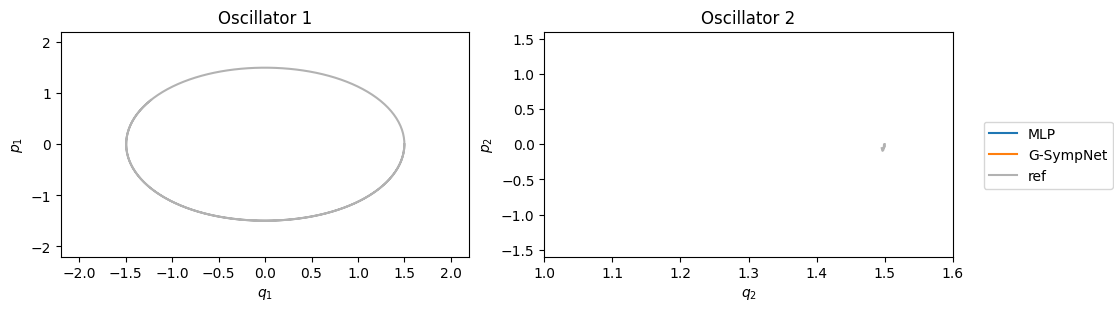

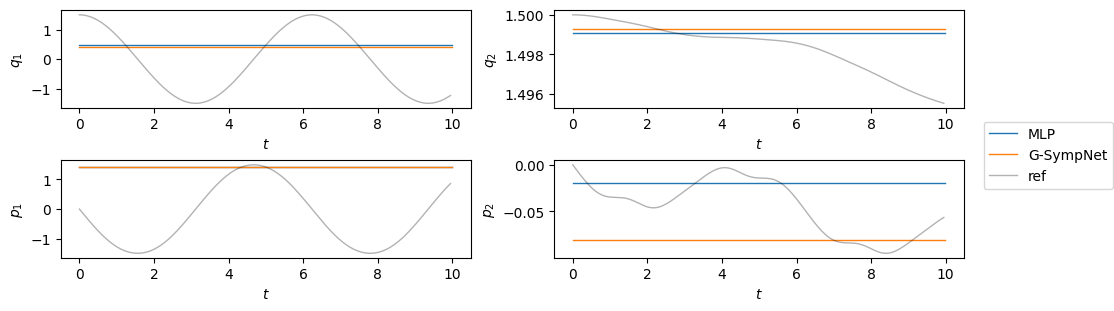

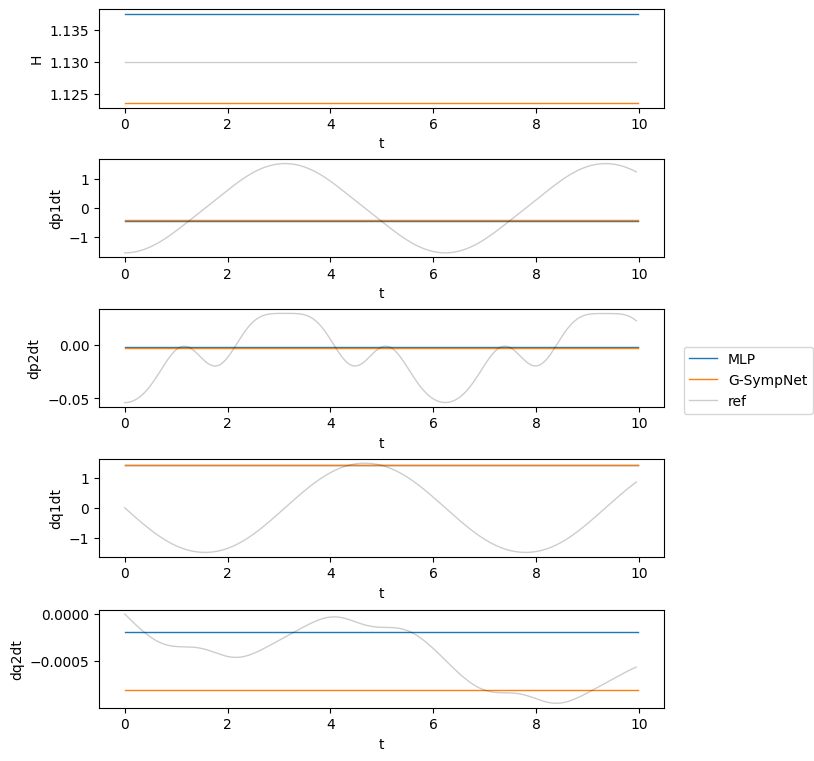

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 9.950000000000001], dt=0.05, u0=[ 1.42678856e+00 -1.95743458e-04  4.76611066e-01  1.49910314e+00], states=States(problem=NCO(epsilon=0.01), shape=(200, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 9.950000000000001], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(200, 4)))
MLP n=1 osc1_rel_traj_err = 1.2118488572467616
MLP n=199 osc1_rel_traj_err = 1.1971659436207192
MLP n=1 osc2_rel_traj_err = 0.01126656619501691
MLP n=199 osc2_rel_traj_err = 0.024715571048592982
MLP n=1 rel_traj_err = 0.8569573347415709
MLP n=199 rel_traj_err = 0.8482407607298021
MLP n=1 abs_H_err = 0.007543016373907863
MLP n=199 abs_H_err = 0.007543016373905198
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 9.950000000000001], dt=0.05, u0=[ 1.43325374e+00 -8.03887403e-04  4.22550092e-01  1.49926962e+00], states=States(problem=NCO(epsilon=0.01), shape=(200, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 9.950000000000001], dt=0

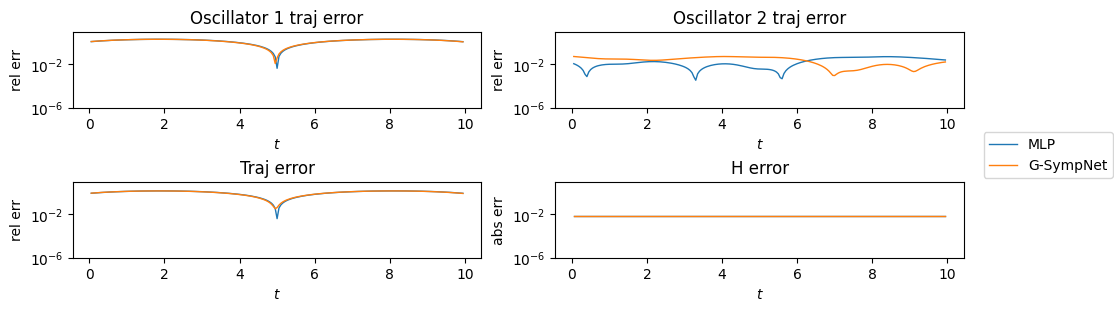

In [29]:
def trajectory_from_taylor_expansion(u0, times, p, order):
    """Generate trajectory using Taylor series expansion."""
    processor = NCO(**p)
    u = processor.compute_taylor_series(u0, times, order)
    return Trajectory.from_vx(times, u, **p)

def build_trajectory_list(pred_trajs, model_labels, ref_traj, coarse_ref_traj, taylor_trajs, 
                         show_coarse_ref, show_taylor, t_list):
    """Build lists of trajectories, labels, and colors for plotting."""
    trajs = pred_trajs.copy()
    labels = model_labels.copy()
    colors = [f"C{i}" for i in range(len(model_labels))]
    
    # Add reference
    if ref_traj:
        trajs.append(ref_traj.select_between(t_list.min(), t_list.max()))
        labels.append("ref")
        colors.append("black")
    
    # Add coarse reference if requested
    if show_coarse_ref and coarse_ref_traj:
        trajs.append(coarse_ref_traj.select_between(t_list.min(), t_list.max()))
        labels.append(r"$\Phi_{VV, h=0.01}$")
        colors.append("grey")
    
    # Add Taylor trajectories if requested
    if show_taylor:
        trajs.extend(taylor_trajs)
        labels.extend([f"Taylor order {i+1}" for i in range(len(taylor_trajs))])
        colors.extend(["red", "green"][:len(taylor_trajs)])
    
    return trajs, labels, colors

# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)
ref_traj_idx = 1

# Display options
show_coarse_ref = False
show_taylor = False
taylor_orders = [1, 2]

# Load trajectories
ref_filepaths = NCO.get_reference_filepaths('constant_energy')
ref_traj = Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

coarse_ref_traj = None
if show_coarse_ref:
    coarse_ref_filepaths = NCO.get_reference_filepaths('vv_constant_energy')
    coarse_ref_traj = Trajectory.load_from_file(
        coarse_ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
        dt=coarse_ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
    )

# Generate predictions
t_list = np.arange(0, 10, 0.01)
pred_trajs = [Trajectory.from_vx(t_list, one_step_predict(model, u0, t_list, params), **params) 
              for model in models]

taylor_trajs = []
if show_taylor:
    taylor_trajs = [trajectory_from_taylor_expansion(u0, t_list, params, order) 
                    for order in taylor_orders]

# --- Plot ---

# Set model labels for plotting
# model_labels_for_plotting = [
#     r"$\Phi_{[0,20]}$", 
#     r"$\Phi_{[0,40]}$", 
#     r"$\Phi_{[0,80]}$"
# ]
model_labels_for_plotting = [
    "MLP",
    "G-SympNet"
]
# If you want to use the original model_labels, uncomment the following line:
# model_labels_for_plotting = model_labels

# Gather all trajectories, their corresponding labels, and colors for visualization
all_trajs, all_labels, all_colors = build_trajectory_list(
    pred_trajs, model_labels_for_plotting, ref_traj, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)

# Set axis limits for phase space plots
# Format: [[(q1_min, q1_max), (p1_min, p1_max)], [(q2_min, q2_max), (p2_min, p2_max)]]
phase_space_axis_lims = [
    [(-2.2, 2.2), (-2.2, 2.2)],   # Oscillator 1: (q1, p1)
    [(1.0, 1.6), (-1.6, 1.6)]     # Oscillator 2: (q2, p2)
]
q1_lim, p1_lim = phase_space_axis_lims[0]
q2_lim, p2_lim = phase_space_axis_lims[1]


# Plot phase space trajectories for both oscillators
viz.plot_phase_space(
    all_trajs,
    axis_lims=phase_space_axis_lims,
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot (q, p) vs time for both oscillators
viz.plot_pq_vs_t(
    all_trajs,
    y_lims=[q1_lim, q2_lim, p1_lim, p2_lim],
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot time histories for key physical quantities
viz.plot_history(
    all_trajs,
    func_dict={
        'H': lambda u: processor.compute_hamiltonian(u),
        'dp1dt': lambda u: processor.compute_du(u)[:, 0],
        'dp2dt': lambda u: processor.compute_du(u)[:, 1],
        'dq1dt': lambda u: processor.compute_du(u)[:, 2],
        'dq2dt': lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t',
    legend_labels=all_labels,
    colors=all_colors,
    show_legend=True,
)

# Plot errors against reference
error_trajs, error_labels, error_colors = build_trajectory_list(
    pred_trajs, model_labels_for_plotting, None, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)
error_linestyles = ["-"] * len(model_labels) + (["--"] if show_coarse_ref else []) + (["-."] * len(taylor_trajs) if show_taylor else [])

viz.plot_errors(
    error_trajs, ref_traj, legend_labels=error_labels, 
    error_names=["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "abs_H_err"], 
    show_legend=True, linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-6, 1e1)]*4, log_xscale=False, figsize=(11, 3),
)

# Plot errors against coarse reference if available
if show_coarse_ref and coarse_ref_traj:
    coarse_error_trajs, coarse_error_labels, coarse_error_colors = build_trajectory_list(
        pred_trajs, model_labels, ref_traj, None, taylor_trajs, False, show_taylor, t_list
    )
    coarse_error_linestyles = ["-"] * len(model_labels) + ["--"] + (["-."] * len(taylor_trajs) if show_taylor else [])
    
    viz.plot_errors(
        coarse_error_trajs, coarse_ref_traj, 
        error_names=["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "abs_H_err"], 
        legend_labels=coarse_error_labels, show_legend=True, 
        linestyles=coarse_error_linestyles, colors=coarse_error_colors,
        ylims=[(1e-6, 1e-2)]*4, log_xscale=True, figsize=(11, 3), 
    )


In [5]:
# error_colors = ["C0", "C2", "C3", "k"]
viz.plot_errors_matlab(
    error_trajs, ref_traj, legend_labels=error_labels, 
    show_legend=True, linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-6, 1e1)]*4, log_xscale=False, figsize=(11, 6),
    save_path=f"./out/nco/eps=1e-2/various_T/errors_matlab.pdf",
)

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(1600, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(1600, 4)))
$\Phi_{[0,20]}$ n=1 osc1_abs_traj_err = 8.381885421257522e-05
$\Phi_{[0,20]}$ n=1599 osc1_abs_traj_err = 145.8525436074626
$\Phi_{[0,20]}$ n=1 osc2_abs_traj_err = 1.0537744771970197e-06
$\Phi_{[0,20]}$ n=1599 osc2_abs_traj_err = 50.55637522272158
$\Phi_{[0,20]}$ n=1 abs_traj_err = 8.382547800136739e-05
$\Phi_{[0,20]}$ n=1599 abs_traj_err = 154.36616064548406
$\Phi_{[0,20]}$ n=1 abs_H_err = 1.8733943305537792e-06
$\Phi_{[0,20]}$ n=1599 abs_H_err = 10778.322872248058
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(1600, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=St

### 3. Recursive Predictions

Repeatedly applying the model with a fixed time step (dt)


Model: MLP (M)
	dt=5.0 Recursive prediction time: 6.37e-02s
Model: G-SympNet (M)
	dt=5.0 Recursive prediction time: 4.28e-01s


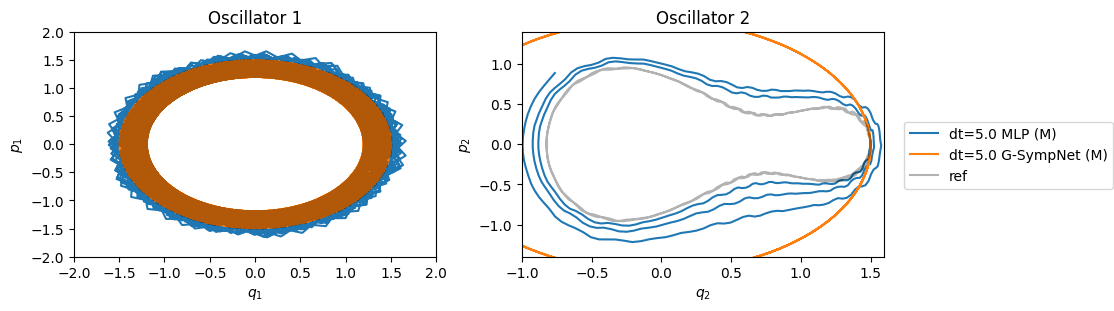

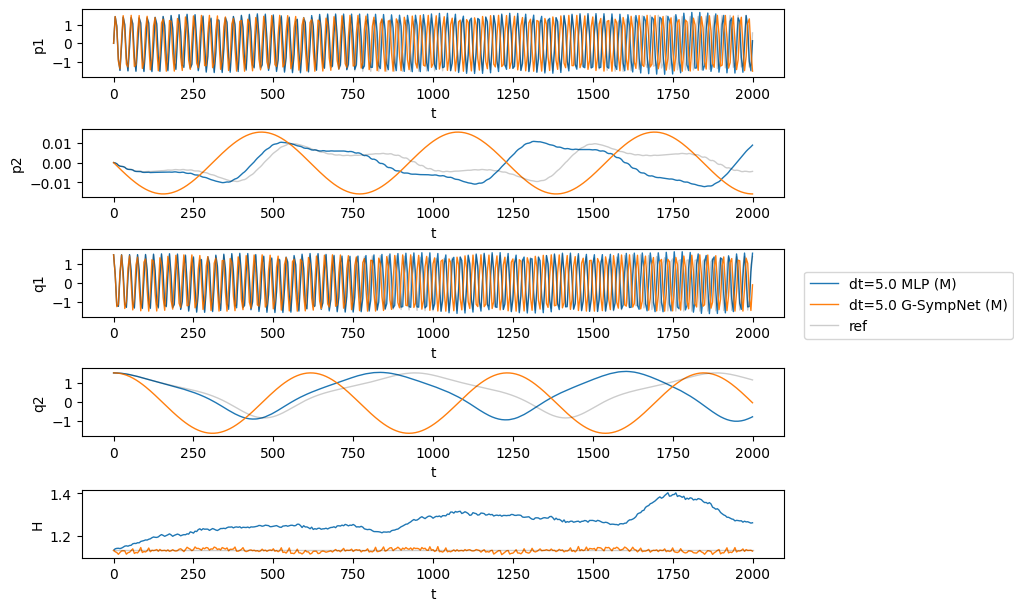

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
dt=5.0 MLP (M) n=1 osc1_rel_traj_err = 0.0042465026003839735
dt=5.0 MLP (M) n=400 osc1_rel_traj_err = 0.30259511906094805
dt=5.0 MLP (M) n=1 osc2_rel_traj_err = 0.0036347324220024836
dt=5.0 MLP (M) n=400 osc2_rel_traj_err = 1.900033524002221
dt=5.0 MLP (M) n=1 abs_traj_err = 0.008379451882374453
dt=5.0 MLP (M) n=400 abs_traj_err = 2.366471545268813
dt=5.0 MLP (M) n=1 rel_H_err = 0.006675453412167288
dt=5.0 MLP (M) n=400 rel_H_err = 0.11588704915400606
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(

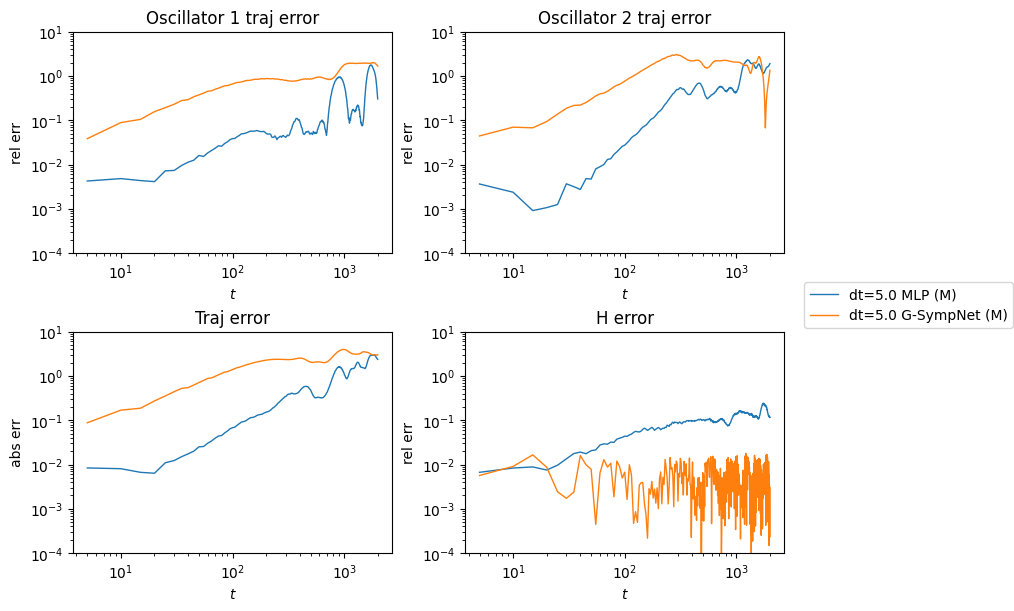

In [5]:
def build_recursive_trajectory_list(pred_trajs, labels, ref_traj, dt_list, T_end):
    """Build lists of trajectories, labels, and colors for recursive prediction plotting."""
    all_trajs = pred_trajs.copy()
    all_labels = labels.copy()
    all_colors = [f"C{i}" for i in range(len(pred_trajs))]
    
    # Add reference trajectory
    ref_traj_selected = ref_traj.select_with_interval(min(dt_list)).select_between(0, T_end)
    all_trajs.append(ref_traj_selected)
    all_labels.append("ref")
    all_colors.append("black")
    
    return all_trajs, all_labels, all_colors

# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)
ref_traj_idx = 1

# Recursive prediction parameters
T_end = 2000
dt_list = [5.0]  # Time steps for recursive evaluation
show_timing = True  # Whether to show prediction timing

# Load reference trajectory
ref_filepaths = NCO.get_reference_filepaths('constant_energy')
ref_traj = Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

# Generate recursive predictions: φ(φ(φ(u₀,dt),dt),dt)...
pred_trajs = []
labels = []
for model, model_label in zip(models, model_labels): 
    if show_timing:
        print(f"Model: {model_label}")
    
    for dt in dt_list:
        if show_timing:
            start = time.time()
        
        u_seq = recursive_predict(model, u0, dt, params, int(T_end//dt)+1)
        
        if show_timing:
            print(f"\tdt={dt} Recursive prediction time: {time.time()-start:.2e}s")
        
        traj = Trajectory.from_vx(np.arange(len(u_seq))*dt, u_seq, **params)
        pred_trajs.append(traj)
        labels.append(f"dt={dt} {model_label}")


# Build trajectory lists for plotting
all_trajs, all_labels, all_colors = build_recursive_trajectory_list(
    pred_trajs, labels, ref_traj, dt_list, T_end
)

# Plot phase space
phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-1, 1.6), (-1.4, 1.4)]]
# phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-14, 14), (-14, 14)]]
viz.plot_phase_space(
    all_trajs, 
    axis_lims=phase_space_axis_lims,
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot trajectory history
viz.plot_history(
    all_trajs,
    func_dict={
        'p1': lambda u: u[:, 0], 'p2': lambda u: u[:, 1],
        'q1': lambda u: u[:, 2], 'q2': lambda u: u[:, 3], 
        'H': lambda u: processor.compute_hamiltonian(u),
    },
    xlabel='t', legend_labels=all_labels, colors=all_colors,
    show_legend=True, figsize=(10, 6),
)

# Plot errors against reference
viz.plot_errors(
    pred_trajs, ref_traj, 
    error_names=["osc1_rel_traj_err", "osc2_rel_traj_err", "abs_traj_err", "rel_H_err"], 
    ylabels=["rel err", "rel err", "abs err", "rel err"],
    legend_labels=labels, show_legend=True, 
    ylims=[(1e-4, 1e1)]*4, log_xscale=True, figsize=(10, 6),
)


#### a. Constant Energy Trajectories 

Reference Trajectories:
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))


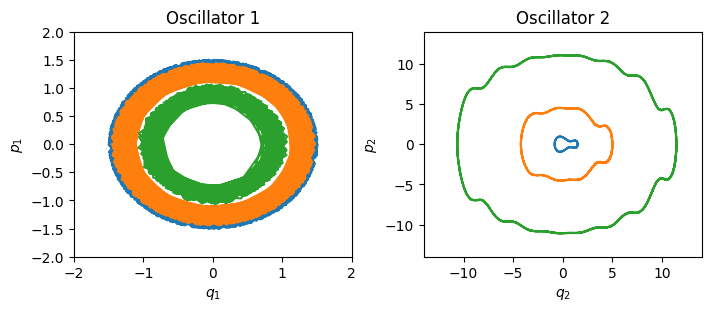

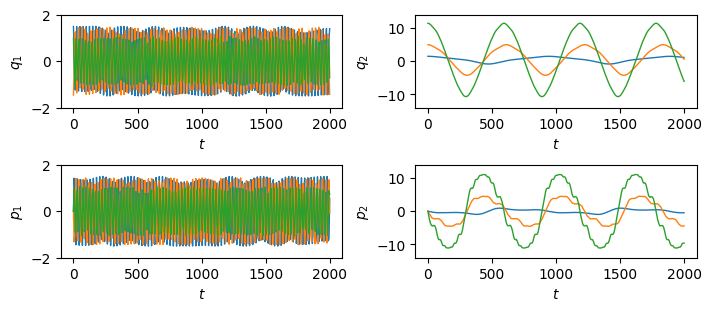

Model: MLP (M)
Dt: 5.0
	Prediction time: 7.36e-02s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))


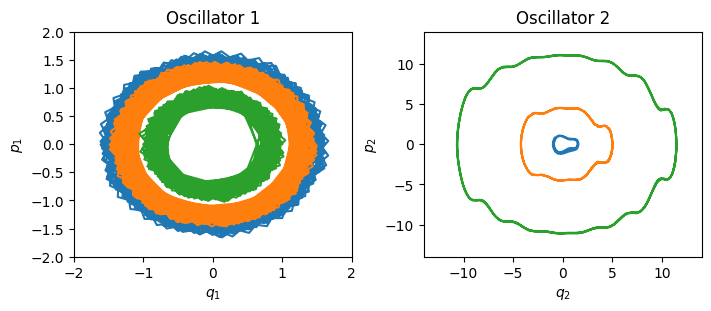

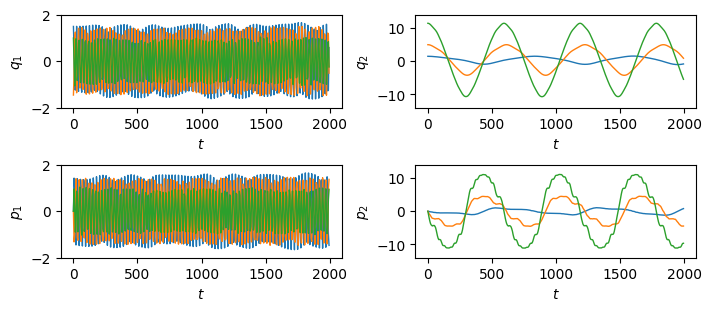

Model: G-SympNet (M)
Dt: 5.0
	Prediction time: 3.79e-01s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))


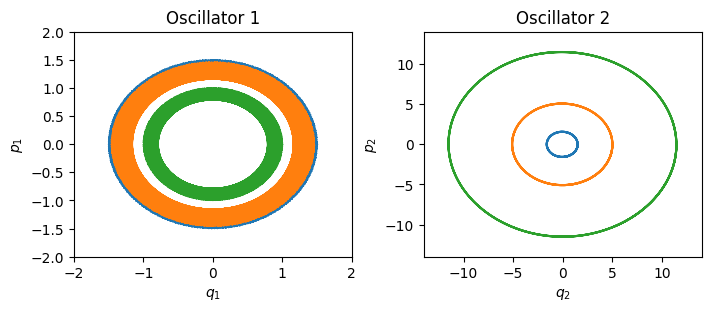

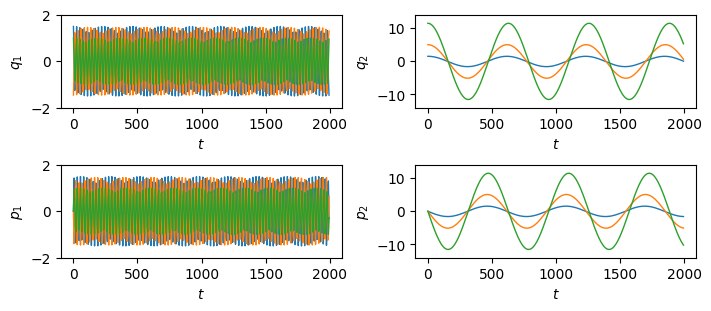

In [6]:
# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)

# Select reference trajectory indices to use as initial conditions
ref_traj_indices = [1, 2, 3]

# Load reference trajectories
ref_filepaths = NCO.get_reference_filepaths('constant_energy')
ref_trajs = [Trajectory.load_from_file(
    ref_filepaths[epsilon][idx]["filepath"], 
    dt=ref_filepaths[epsilon][idx]["dt"],
    **params
) for idx in ref_traj_indices]

# Extract initial conditions
u0_list = [ref_traj.states.u[0] for ref_traj in ref_trajs]

# Simulation parameters
T_end = 2000
dt_list = [5.0]

# Phase space axis limits for plotting
phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-14, 14), (-14, 14)]]
q1_lim, p1_lim = phase_space_axis_lims[0]
q2_lim, p2_lim = phase_space_axis_lims[1]

print("Reference Trajectories:")
trajs = [ref_traj.select_between(0, T_end).select_with_interval(min(dt_list)) for ref_traj in ref_trajs]
for traj in trajs:
    print(traj)
    
# Plot reference trajectories
viz.plot_phase_space(
    trajs, 
    axis_lims=phase_space_axis_lims,
    figsize=(7, 3),
    show_legend=False
)

# viz.plot_phase_space_matlab(
#     trajs, 
#     axis_lims=phase_space_axis_lims,
#     show_legend=False,
#     figsize=(5,2),
#     # save_path=f"../out/nco/eps=1e-2/various_T/various_T_phase_space_ref.pdf"
# )

viz.plot_pq_vs_t(
    trajs, 
    ylims=[q1_lim, q2_lim, p1_lim, p2_lim], 
    figsize=(7, 3),
    show_legend=False,
)

# Generate predictions for each model and initial condition
for model, label in zip(models, model_labels):
    for dt in dt_list:
        print(f"Model: {label}\nDt: {dt}")
    
        pred_trajs = []
        start = time.time()
        u_seq_list = recursive_predict(model, u0_list, dt, params, int(T_end//dt))
        print(f"\tPrediction time: {time.time()-start:.2e}s")
        
        for u_seq in u_seq_list:
            traj = Trajectory.from_vx(np.arange(len(u_seq))*dt, u_seq, **params)
            print(traj)
            pred_trajs.append(traj)

        # Plot predicted trajectories
        viz.plot_phase_space(
            pred_trajs, 
            axis_lims=phase_space_axis_lims,
            figsize=(7, 3),
            show_legend=False,
        )

        # viz.plot_phase_space_matlab(
        #     pred_trajs, 
        #     axis_lims=phase_space_axis_lims,
        #     show_legend=False,
        #     figsize=(5,2),
        #     save_path=f"../out/nco/eps=1e-2/arch/arch_phase_space_{label}.pdf"
        # )

        viz.plot_pq_vs_t(
            pred_trajs, 
            ylims=[q1_lim, q2_lim, p1_lim, p2_lim],
            figsize=(7, 3),
            show_legend=False,
        )


#### b. Fixed $q_1$ Trajectories

Reference Trajectories:
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0. ], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.   0.   1.5  0.15], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0.4], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1. ], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.   0.   1.5  1.45], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.   0.   1.5  1.55], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 4. ], states=States(problem=

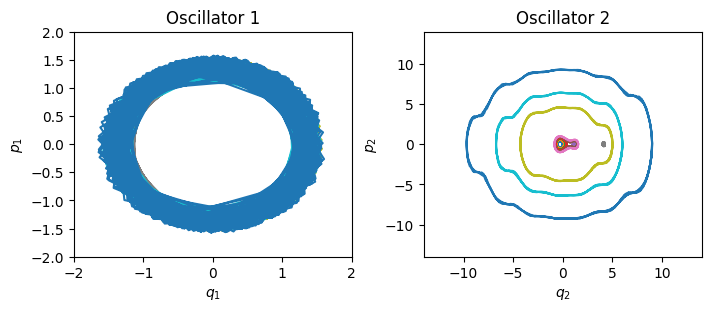

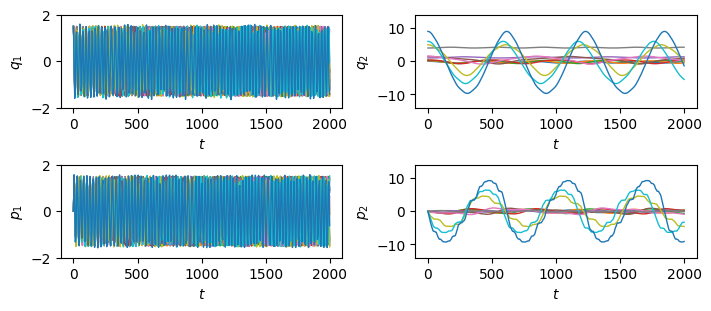

Model: MLP (M)
Dt: 5.0
	Prediction time: 1.08e-01s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  0.15], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.4], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.45], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.55], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 4

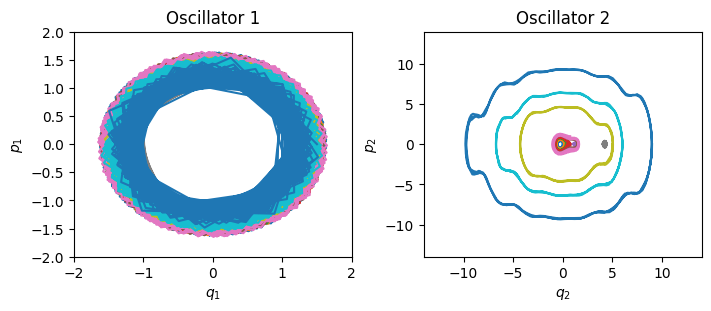

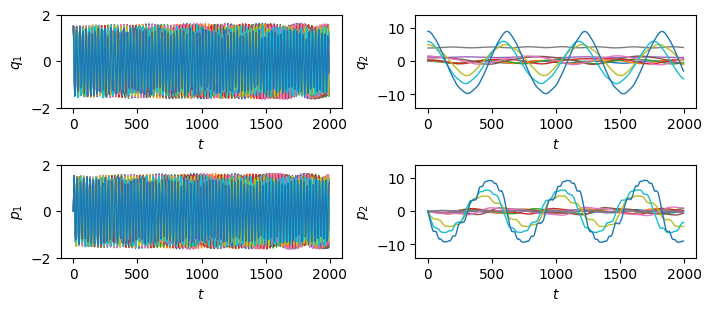

Model: G-SympNet (M)
Dt: 5.0
	Prediction time: 7.79e-01s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  0.15], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.4], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.45], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.55], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0. 

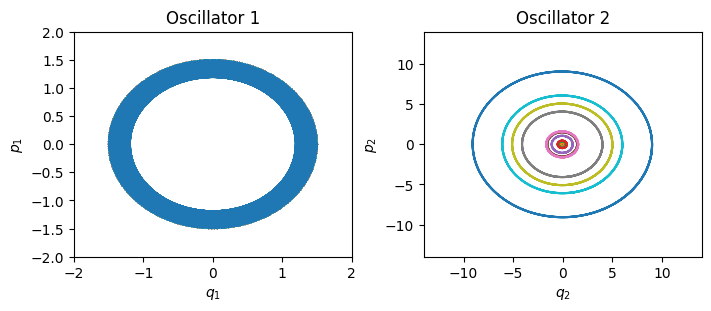

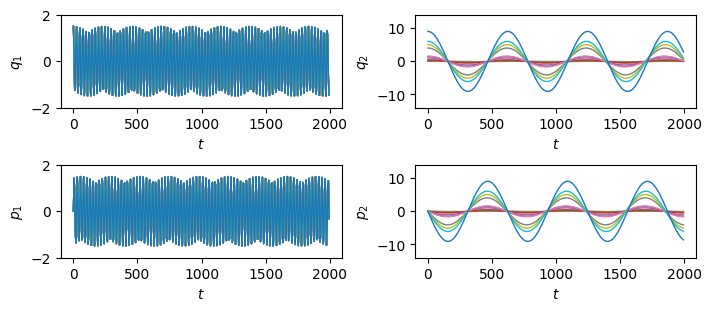

In [7]:
# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)

# Select reference trajectory indices to use as initial conditions
ref_traj_indices = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

# Load reference trajectories
ref_filepaths = NCO.get_reference_filepaths('fixed_q1')
ref_trajs = [Trajectory.load_from_file(
    ref_filepaths[epsilon][idx]["filepath"], 
    dt=ref_filepaths[epsilon][idx]["dt"],
    **params
) for idx in ref_traj_indices]

# Extract initial conditions
u0_list = [ref_traj.states.u[0] for ref_traj in ref_trajs]

# Simulation parameters
T_end = 2000
dt_list = [5.0]

# Phase space axis limits for plotting
# phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-1, 1.6), (-1.4, 1.4)]]
phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-14, 14), (-14, 14)]]
q1_lim, p1_lim = phase_space_axis_lims[0]
q2_lim, p2_lim = phase_space_axis_lims[1]

print("Reference Trajectories:")
trajs = [ref_traj.select_between(0, T_end).select_with_interval(min(dt_list)) for ref_traj in ref_trajs]
for traj in trajs:
    print(traj)
    
# Plot reference trajectories
viz.plot_phase_space(
    trajs, 
    axis_lims=phase_space_axis_lims,
    figsize=(7, 3),
    show_legend=False,
)

# viz.plot_phase_space_matlab(
#     trajs, 
#     axis_lims=phase_space_axis_lims,
#     show_legend=False,
#     figsize=(5,2),
#     # save_path=f"../out/nco/eps=1e-2/best/phase_space_fixedq1_ref.pdf"
# )

viz.plot_pq_vs_t(
    trajs, 
    ylims=[q1_lim, q2_lim, p1_lim, p2_lim], 
    figsize=(7, 3),
    show_legend=False,
)

# Generate predictions for each model and initial condition
for model, label in zip(models, model_labels):
    for dt in dt_list:
        print(f"Model: {label}\nDt: {dt}")
    
        pred_trajs = []
        start = time.time()
        u_seq_list = recursive_predict(model, u0_list, dt, params, int(T_end//dt))
        print(f"\tPrediction time: {time.time()-start:.2e}s")
        
        for u_seq in u_seq_list:
            traj = Trajectory.from_vx(np.arange(len(u_seq))*dt, u_seq, **params)
            print(traj)
            pred_trajs.append(traj)

        # Plot predicted trajectories
        viz.plot_phase_space(
            pred_trajs, 
            axis_lims=phase_space_axis_lims,
            figsize=(7, 3),
            show_legend=False,
        )

        # viz.plot_phase_space_matlab(
        #     pred_trajs, 
        #     axis_lims=phase_space_axis_lims,
        #     show_legend=False,
        #     figsize=(5,2),
        #     save_path=f"../out/nco/eps=1e-2/best/phase_space_fixedq1_{label}.pdf"
        # )

        viz.plot_pq_vs_t(
            pred_trajs, 
            ylims=[q1_lim, q2_lim, p1_lim, p2_lim],
            figsize=(7, 3),
            show_legend=False,
        )
